In [44]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from stable_baselines3.common.monitor import Monitor
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import torch

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citations.citation_loader as citation_loader
importlib.reload(citation_loader)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay

In [42]:
users_loader = CitationUsersLoader("../environment/users/datasets/users_with_popular_interests.json")
user_list = users_loader.get_users()
paper_loader = CitationsLoader("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
selector = CitationsSelector()
rater = RuleBasedCitationRater()
reward_shaping = CitationRewardReshapingExpDecay()

In [45]:
user_rewards = []
timesteps = 30000

for user in user_list:
    env = UserEnv(
        render_mode= "human",
        items_loader=paper_loader,
        user_list=[user],
        items_selector=selector,
        reward_shaping=reward_shaping,
        render_path="./tmp/render/",
        debug=True,
        debug_path=f"debug_log/user_env_PPO_user{user.id}_{timesteps}.log",
    )
    env = Monitor(env, filename=f"monitor_PPO_user{user.id}.csv", info_keywords=("user_id", "item_interact", "item_clicks"))

    model = PPO(
        policy="MultiInputPolicy",
        env=env,
        verbose=1,
        device="cpu",
        learning_rate=1e-4,          # You can tune this
        n_steps=2048,                # Number of steps to run for each environment per update
        batch_size=128,              # Minibatch size
        n_epochs=10,                 # Number of epoch when optimizing the surrogate loss
        gamma=0.99,                  # Discount factor
        clip_range=0.2,              # Clipping parameter for PPO
        ent_coef=0.01,               # Entropy coefficient to encourage exploration
    )

    model.learn(total_timesteps=timesteps)
    user_rewards.append(env.get_episode_rewards())


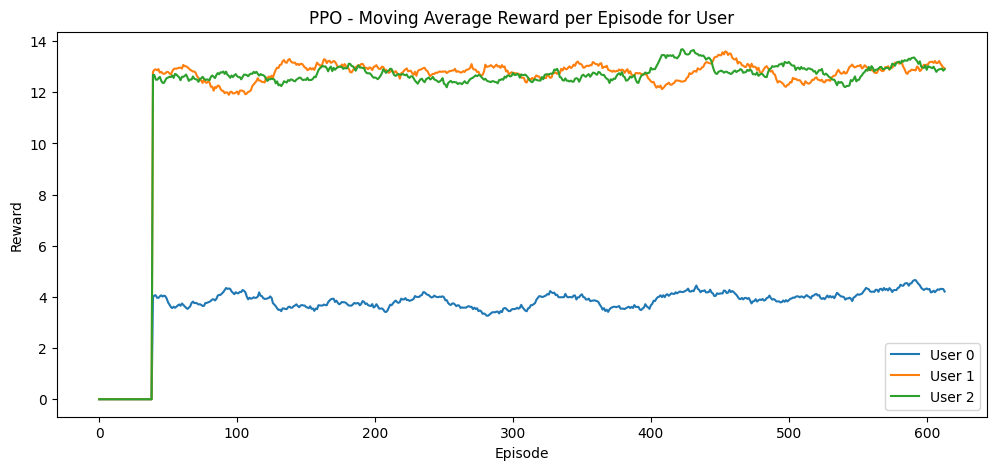

In [46]:
def plot_rewards(all_user_rewards, window_size=40):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title(f"PPO - Moving Average Reward per Episode for User")

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()
    plt.savefig(
        "export_images/PPO Moving Average Reward.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )
    plt.show()

plot_rewards(user_rewards)

# Evaluation

In [ ]:
import pandas as pd
import re
import ast

In [ ]:
def to_int_tuple(s: str):
    # 1) replace np.int64(123) with just 123
    cleaned = re.sub(r'np\.int64\(\s*(\d+)\s*\)', r'\1', s)
    # 2) literal_eval the result to get a Python tuple of ints
    return ast.literal_eval(cleaned)

# apply it to your DataFrame
df = pd.read_csv("monitor_A2C_user0.csv.monitor.csv", skiprows=1)
df['item_interact_tuple'] = df['item_interact'].apply(to_int_tuple)
df['item_clicks_tuple'] = df['item_clicks'].apply(to_int_tuple)

In [ ]:
df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].nunique()

22595

In [ ]:
interacted_papers_id = df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].unique()
interacted_papers = paper_loader.load_items_from_ids(interacted_papers_id)
recommended_papers = {
    "id": [],
    "title": [],
    "publication_year": [],
    "quartile_year": [],
    "cited_by_count": [],
    "quartile_cite": [],
    "topics": [],
    # "clicked": []
}

for i in range(len(interacted_papers)):
    recommended_papers["id"].append(interacted_papers[i].id)
    recommended_papers["title"].append(interacted_papers[i].title)
    recommended_papers["publication_year"].append(interacted_papers[i].year)
    recommended_papers["quartile_year"].append(interacted_papers[i].quartile_year)
    recommended_papers["cited_by_count"].append(interacted_papers[i].cited_by_count)
    recommended_papers["quartile_cite"].append(interacted_papers[i].quartile_cite)
    recommended_papers["topics"].append(interacted_papers[i].topics)
    # recommended_papers["clicked"].append(df['item_clicks_tuple'][i])

recommended_papers_df = pd.DataFrame(recommended_papers)
recommended_papers_df

,id,title,publication_year,quartile_year,cited_by_count,quartile_cite,topics
0,33506,Research Guides: Research Toolkit: What is pee...,2016,0.626263,0,0.000000,[scientometrics and bibliometrics research]
1,6863,Comparison of bibliometric measures for assess...,2015,0.570707,21,0.863636,"[scientometrics and bibliometrics research, Me..."
2,14886,A Test of Two Citation Checking Techniques for...,1983,0.136364,12,0.797980,[scientometrics and bibliometrics research]
3,39705,Referees' Decisions: academic publishing,2013,0.464646,0,0.000000,"[scientometrics and bibliometrics research, He..."
4,24093,Can we use link-based indicators to find highl...,2022,0.868687,2,0.580808,"[scientometrics and bibliometrics research, We..."
...,...,...,...,...,...,...,...
22590,34591,Embracing open access and offering greater cho...,2015,0.570707,0,0.000000,[scientometrics and bibliometrics research]
22591,39369,A quantitative analysis on career flow of high...,2011,0.368687,0,0.000000,[scientometrics and bibliometrics research]
22592,9206,Peer review practices: a content analysis of e...,2010,0.333333,19,0.853535,"[scientometrics and bibliometrics research, Cl..."
22593,9033,The status of research productivity in communi...,1999,0.185185,31,0.898990,"[scientometrics and bibliometrics research, Ma..."


## Diversity

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
from sentence_transformers import SentenceTransformer

In [ ]:
dataset = pd.read_csv("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
sampled_dataset = dataset.sample(
    n=recommended_papers_df.shape[0],
    replace=True,                      # allow repeats
    weights='cited_by_count',          # use this column as relative weights
    random_state=42
)

### Topics

In [ ]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")
all_embeddings = []
for topics in recommended_papers_df['topics']:
    # get each topic’s 384‑d vector
    vecs = bert_model.encode(topics, convert_to_tensor=False)
    avg = np.mean(vecs, axis=0)
    all_embeddings.append(avg)

embeddings = np.vstack(all_embeddings)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

recommended_papers_df['x'] = coords[:, 0]
recommended_papers_df['y'] = coords[:, 1]

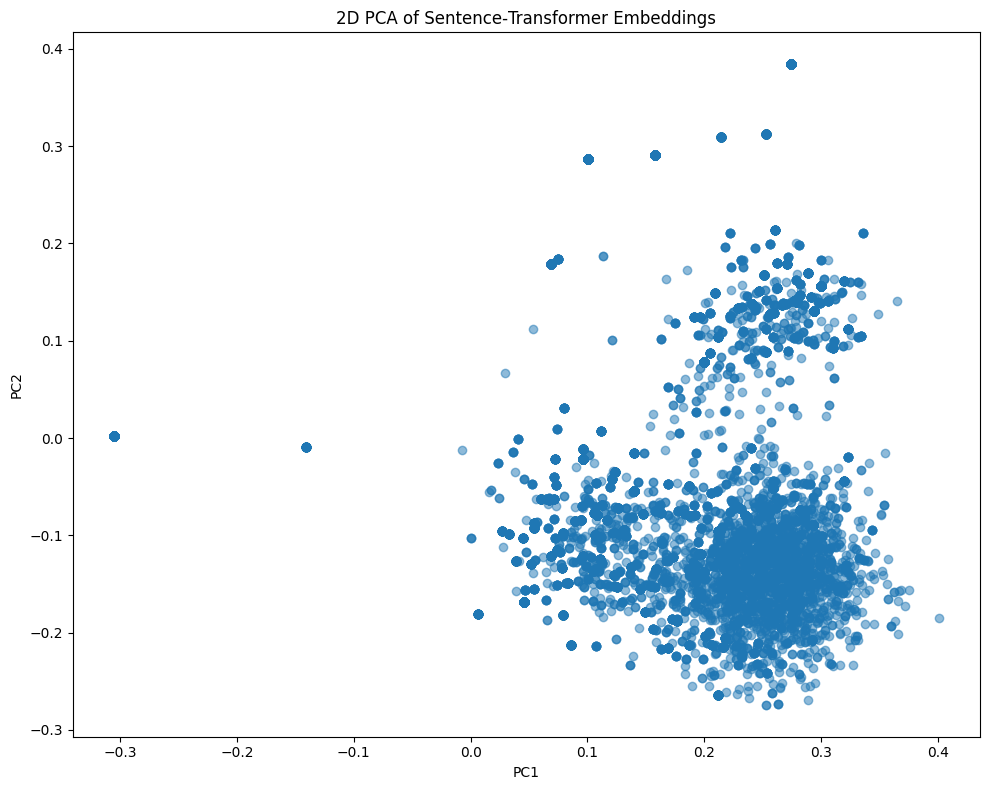

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(recommended_papers_df['x'], recommended_papers_df['y'], alpha=0.5)
plt.title("2D PCA of Sentence‑Transformer Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

### Novelty

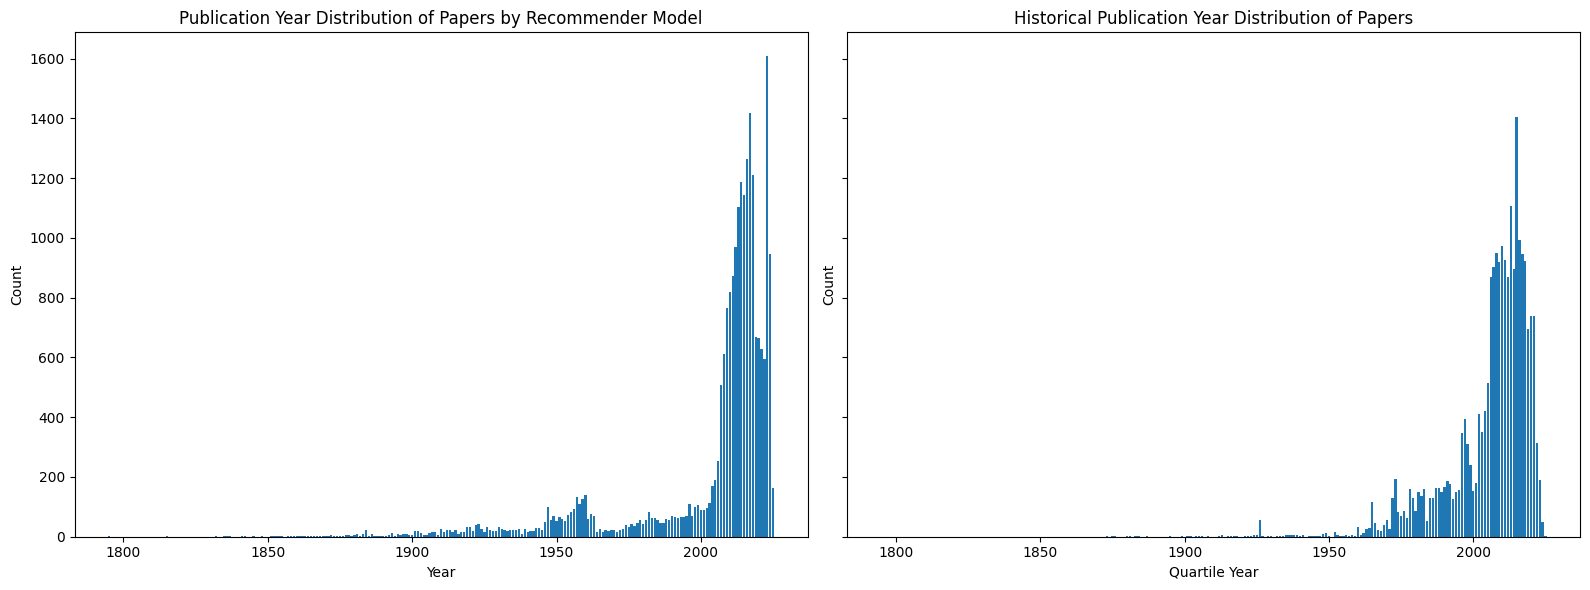

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

ax1.bar(recommended_papers_df['publication_year'].value_counts().index, recommended_papers_df['publication_year'].value_counts().values)
ax1.set_title("Publication Year Distribution of Papers by Recommender Model")
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")

ax2.bar(sampled_dataset['publication_year'].value_counts().index, sampled_dataset['publication_year'].value_counts().values)
ax2.set_title("Historical Publication Year Distribution of Papers")
ax2.set_xlabel("Quartile Year")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Reputability

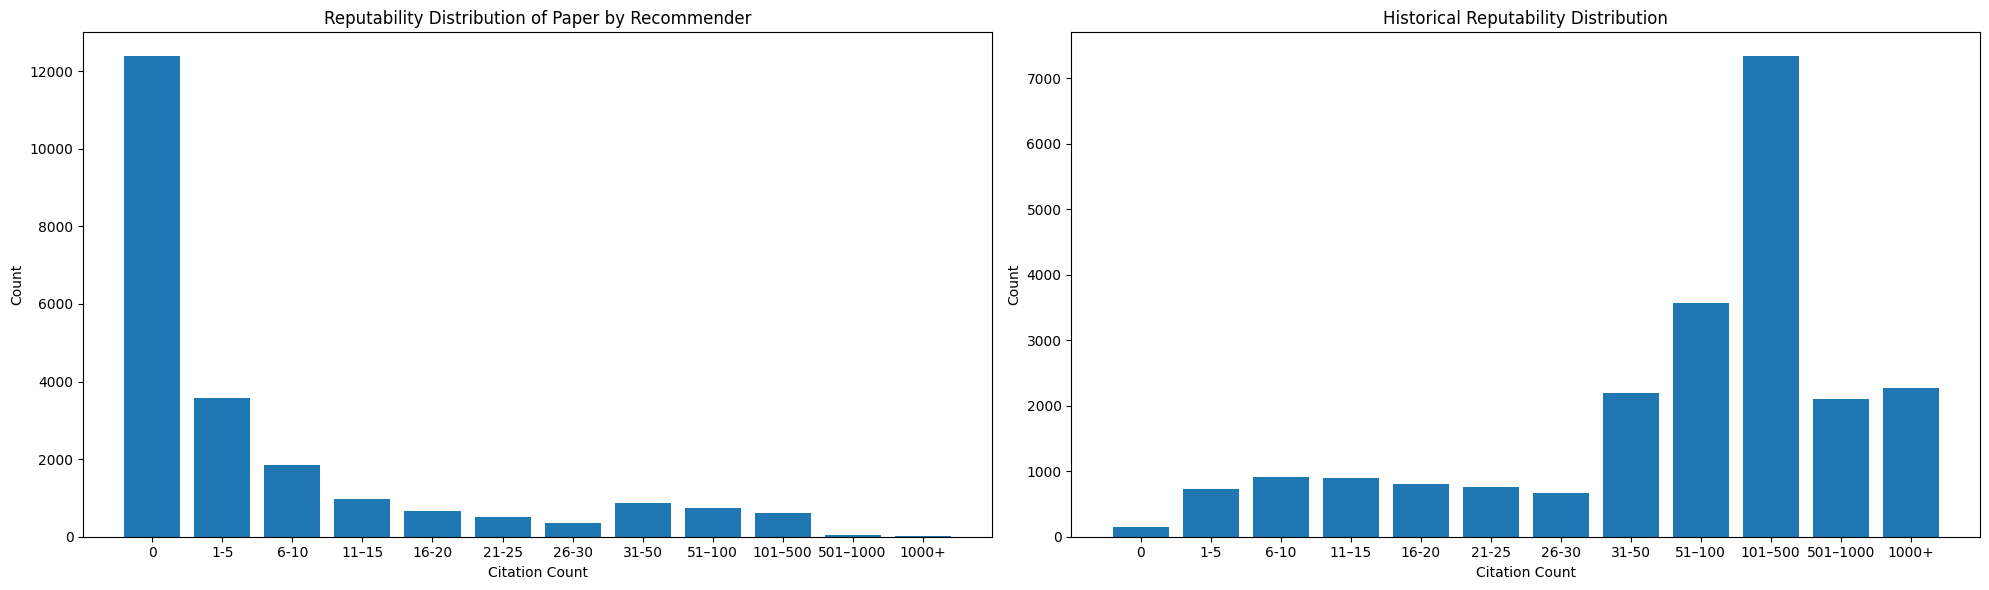

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

bins = [0, 1, 5, 10, 15, 20, 25, 30, 50, 100, 500, 1000, recommended_papers_df['cited_by_count'].max()]
labels = ['0', '1-5', '6-10', '11–15', '16-20', '21-25', '26-30', '31-50', '51–100', '101–500', '501–1000', '1000+']

cited_by_count = pd.cut(recommended_papers_df['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax1.bar(cited_by_count.index, cited_by_count.values)
ax1.set_title("Reputability Distribution of Paper by Recommender")
ax1.set_xlabel("Citation Count")
ax1.set_ylabel("Count")

dataset_cited_by_count = pd.cut(sampled_dataset['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax2.bar(dataset_cited_by_count.index, dataset_cited_by_count.values)
ax2.set_title("Historical Reputability Distribution")
ax2.set_xlabel("Citation Count")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Overall

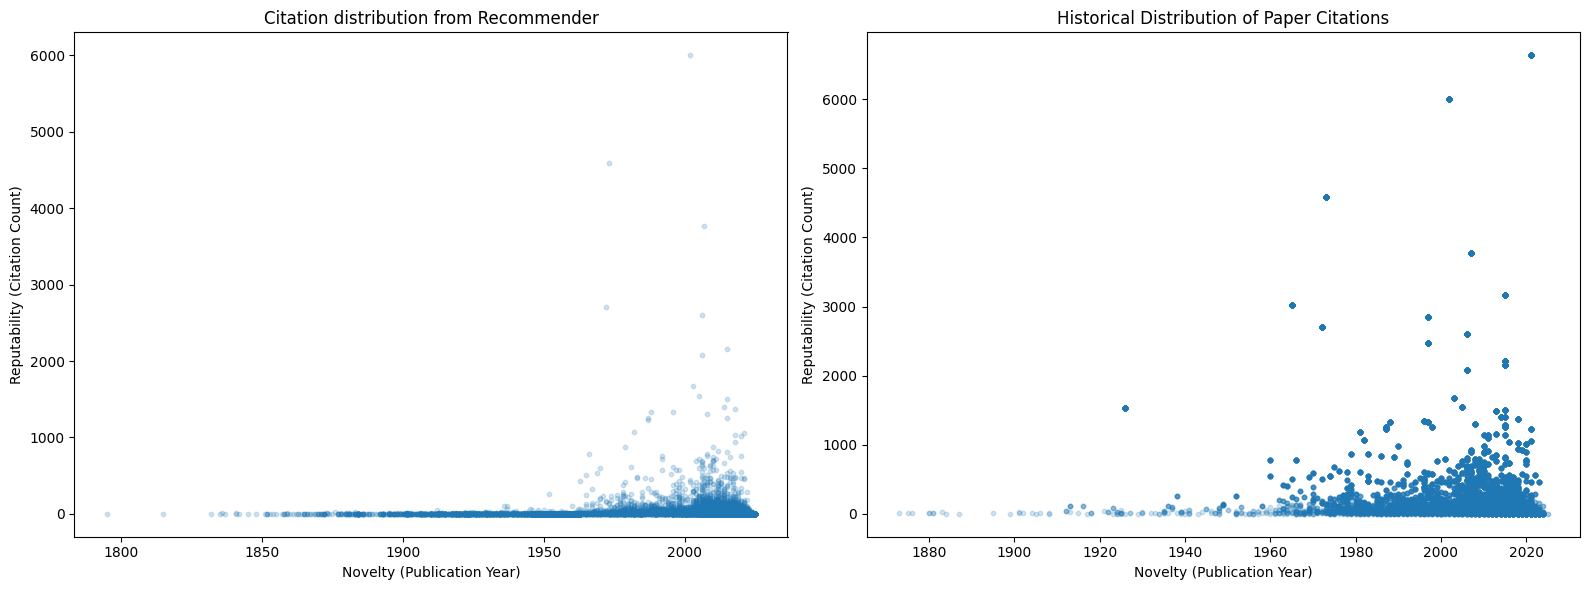

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(recommended_papers_df['publication_year'], recommended_papers_df['cited_by_count'], alpha=0.2, s=10)
ax1.set_title("Citation distribution from Recommender")
ax1.set_xlabel("Novelty (Publication Year)")
ax1.set_ylabel("Reputability (Citation Count)")

ax2.scatter(sampled_dataset['publication_year'], sampled_dataset['cited_by_count'], alpha=0.2, s=10)
ax2.set_title("Historical Distribution of Paper Citations")
ax2.set_xlabel("Novelty (Publication Year)")
ax2.set_ylabel("Reputability (Citation Count)")

plt.tight_layout()
plt.show()